#  Mental Health Crisis Detection

##  Imports

In [ ]:
!pip install nlpaug
import re
import random
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, accuracy_score,
    recall_score, precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from imblearn.over_sampling import SMOTE
from scipy.stats import f_oneway

import nlpaug.augmenter.word as naw
import nlpaug.augmenter.char as nac

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

SAVE_DIR = './saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)
print('All imports successful ✓')
print(f'Models will be saved to: {SAVE_DIR}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 11.3 MB/s eta 0:00:00
All imports successful ✓
Models will be saved to: ./saved_models



##  Data Understanding

### 1.1 Load & First Look

In [ ]:
DATA_PATH = '/content/mental_health_posts.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'mental_health_posts.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (10200, 16)


,post_id,user_id,timestamp,platform,text,label,category,sentiment,risk_score,upvotes,age_group,gender,region,moderator_flag,session_browser,char_count
0,1,USR_39809,2021-08-09 15:31:00,Anonymous_Forum,I've written goodbye letters to my family. I t...,crisis_alert,Information Request,Negative,0.8896,NaN,35-44,Female,Northeast_US,Yes,Firefox,59
1,2,USR_66321,2023-05-17 03:02:00,Crisis_Helpline_App,I called a hotline and they put me on hold for...,Crisi,Eating Disorder,Negative,0.7852,43.0,18-24,Female,UK,No,Edge,66
2,3,USR_90468,2023-12-06 21:32:00,Crisis_Helpline_App,Sharing my experience with EMDR therapy in cas...,Info,Resource Sharing,Negative,0.4417,NaN,45-54,Prefer_not_to_say,Northeast_US,No,Safari,64
3,4,USR_51328,2023-01-06 03:45:00,Crisis_Helpline_App,NaN,Supportive,Community Support,Neutral,0.1392,177.0,45-54,Female,Nigeria,Yes,Edge,0
4,5,USR_66402,2022-06-22 16:18:00,Twitter,Three hospitalizations this year and I still d...,CrisisAlert,Substance Abuse,Very Negative,0.8368,5.0,13-17,NaN,Northeast_US,Yes,Chrome,60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   post_id          10200 non-null  int64  
 1   user_id          10200 non-null  object 
 2   timestamp        10200 non-null  object 
 3   platform         9796 non-null   object 
 4   text             9908 non-null   object 
 5   label            10200 non-null  object 
 6   category         9889 non-null   object 
 7   sentiment        9979 non-null   object 
 8   risk_score       10200 non-null  float64
 9   upvotes          9433 non-null   float64
 10  age_group        9592 non-null   object 
 11  gender           9425 non-null   object 
 12  region           9746 non-null   object 
 13  moderator_flag   10200 non-null  object 
 14  session_browser  10200 non-null  object 
 15  char_count       10200 non-null  int64  
dtypes: float64(2), int64(2), object(12)
memory usage: 1.2+ MB


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

,Missing Count,Missing %
gender,775,7.60
upvotes,767,7.52
age_group,608,5.96
region,454,4.45
platform,404,3.96
category,311,3.05
text,292,2.86
sentiment,221,2.17


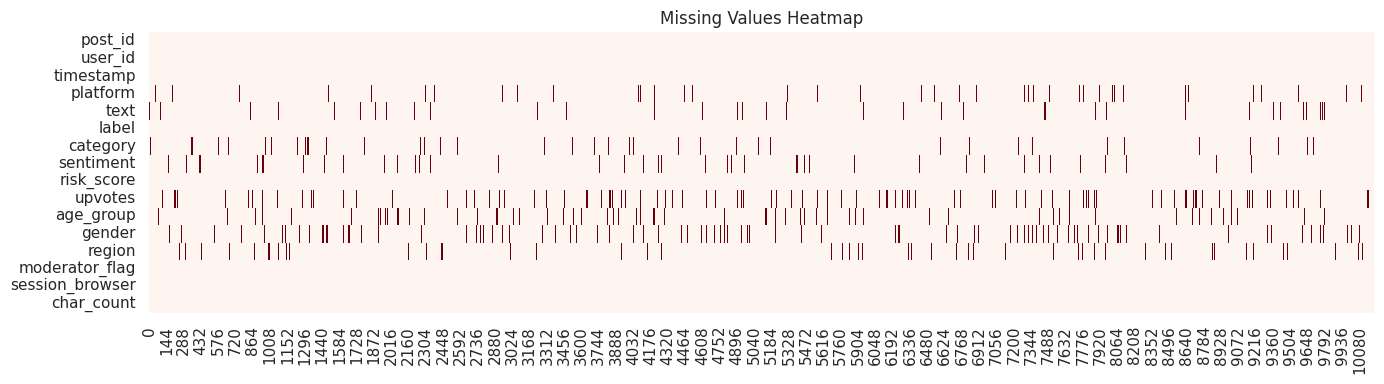

In [ ]:
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=True, cmap='Reds')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
print('Raw label variants found:')
print(df['label'].value_counts().to_string())

Raw label variants found:
label
neutral_info    1096
Neutral         1093
Info            1076
Neutral         1067
Nutral          1066
neutral         1059
NEUTRAL         1021
Suport           242
Supportive       235
Support          235
SUPPORT          233
supportive       230
Support          209
support          207
CrisisAlert      171
crisis           169
CRISIS           169
Crisis           165
Crisi            156
crisis_alert     152
Crisis           149


In [ ]:
raw_label_map = {
    'crisis': 'Crisis', 'crisis_alert': 'Crisis', 'crisisalert': 'Crisis',
    'crisi': 'Crisis', 'crisis ': 'Crisis', 'CRISIS': 'Crisis', 'Crisis': 'Crisis',
    'support': 'Support', 'support ': 'Support', 'SUPPORT': 'Support',
    'suport': 'Support', 'supportive': 'Support', 'Supportive': 'Support', 'Support': 'Support',
    'neutral': 'Neutral', 'neutral ': 'Neutral', 'NEUTRAL': 'Neutral',
    'nutral': 'Neutral', 'neutral_info': 'Neutral', 'info': 'Neutral',
    'Info': 'Neutral', 'Neutral': 'Neutral', 'Nutral': 'Neutral'
}
df['label_clean'] = df['label'].str.strip().map(raw_label_map)

groups = [df[df['label_clean'] == l]['risk_score'].dropna() for l in ['Crisis', 'Support', 'Neutral']]
stat, p = f_oneway(*groups)
print(f'risk_score ANOVA → F={stat:.1f}, p={p:.2e}')

risk_score ANOVA → F=5997.8, p=0.00e+00


In [ ]:
dup_count = df.duplicated(subset=['text', 'user_id', 'timestamp']).sum()
print(f'Duplicate rows (same text + user + timestamp): {dup_count} ({dup_count/len(df)*100:.1f}%)')

Duplicate rows (same text + user + timestamp): 200 (2.0%)


count    9908.000000
mean       70.774929
std        82.447241
min         2.000000
25%        61.000000
50%        65.000000
75%        69.000000
max      1460.000000
Name: text_len, dtype: float64


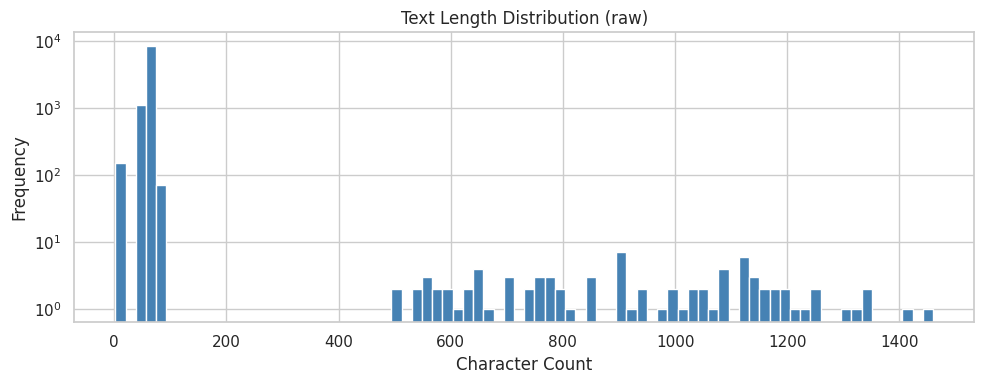

In [ ]:
df['text_len'] = df['text'].dropna().apply(len)
print(df['text_len'].describe())

plt.figure(figsize=(10, 4))
plt.hist(df['text_len'].dropna(), bins=80, color='steelblue', edgecolor='white')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.title('Text Length Distribution (raw)')
plt.yscale('log')
plt.tight_layout()
plt.show()

---
##  Data Cleaning & Preprocessing

### 2.1 Remove Leakage & Irrelevant Columns

In [ ]:
LEAKAGE_COLS = ['risk_score', 'moderator_flag', 'session_browser', 'char_count']
df = df.drop(columns=LEAKAGE_COLS)
print(f'Columns after dropping leakage: {df.shape[1]}')
print(df.columns.tolist())

Columns after dropping leakage: 14
['post_id', 'user_id', 'timestamp', 'platform', 'text', 'label', 'category', 'sentiment', 'upvotes', 'age_group', 'gender', 'region', 'label_clean', 'text_len']


### 2.2 Deduplicate

In [ ]:
before = len(df)
df = df.drop_duplicates(subset=['text', 'user_id', 'timestamp'], keep='first')
print(f'Removed {before - len(df)} duplicate rows → {len(df)} remaining')

Removed 200 duplicate rows → 10000 remaining


### 2.3 Normalize Labels

In [ ]:
label_map = {
    'crisis': 'Crisis', 'crisis_alert': 'Crisis', 'crisisalert': 'Crisis',
    'crisi': 'Crisis', 'crisis ': 'Crisis', 'crisis': 'Crisis',
    'support': 'Support', 'suport': 'Support', 'supportive': 'Support', 'support ': 'Support',
    'neutral': 'Neutral', 'nutral': 'Neutral', 'neutral_info': 'Neutral',
    'neutral ': 'Neutral', 'info': 'Neutral'
}

df['label'] = df['label'].str.strip().str.lower().map(label_map)
df = df.dropna(subset=['label'])

print(df['label'].value_counts())

label
Neutral    7330
Support    1562
Crisis     1108
Name: count, dtype: int64


### 2.4 Handle Missing Values

In [ ]:
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']

for col in ['gender', 'age_group', 'region', 'platform', 'category', 'sentiment']:
    df[col] = df[col].fillna('Unknown')

df['upvotes'] = pd.to_numeric(df['upvotes'], errors='coerce')
df['upvotes'] = df['upvotes'].fillna(df['upvotes'].median())
upper = df['upvotes'].quantile(0.99)
df['upvotes'] = df['upvotes'].clip(upper=upper)

print(f'Remaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

Remaining nulls:
label_clean    541
dtype: int64


### 2.5 Text Cleaning

In [ ]:
SLANG = {
    'bc': 'because', 'u': 'you', 'r': 'are', 'w/': 'with',
    'idk': 'i do not know', 'rn': 'right now', 'smh': 'disappointed',
    'lol': '', 'tbh': 'to be honest', 'ngl': 'not going to lie',
    'imo': 'in my opinion', 'btw': 'by the way'
}

def clean_text(text):
    text = str(text).lower().strip()
    for k, v in SLANG.items():
        text = re.sub(r'\b' + re.escape(k) + r'\b', v, text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text_clean'] = df['text'].apply(clean_text)

before = len(df)
df = df[df['text_clean'].str.len().between(10, 2000)]
print(f'Dropped {before - len(df)} text outliers (too short or too long)')
print(f'Dataset size: {len(df)}')

Dropped 149 text outliers (too short or too long)
Dataset size: 9568


In [ ]:
print('Before:', df['text'].iloc[0][:120])
print('After :', df['text_clean'].iloc[0][:120])

Before: I've written goodbye letters to my family. I think I'm done
After : i ve written goodbye letters to my family i think i m done


---
##  Exploratory Data Analysis (EDA)

### 3.1 Class Distribution

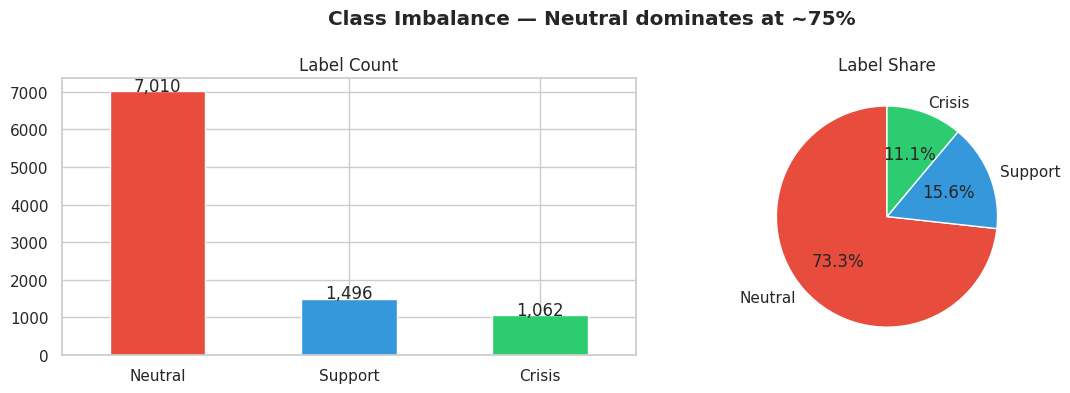

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white')
axes[0].set_title('Label Count')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()+10), ha='center')

counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
            colors=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].set_title('Label Share')
axes[1].set_ylabel('')

plt.suptitle('Class Imbalance — Neutral dominates at ~75%', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Text Length by Label

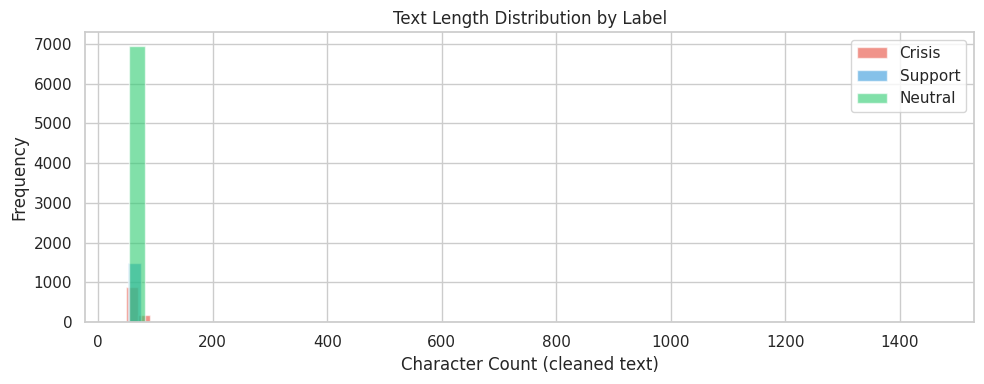

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Crisis,1062.0,69.1,78.5,48.0,57.0,61.0,65.0,1121.0
Neutral,7010.0,71.5,82.1,53.0,61.0,65.0,69.0,1459.0
Support,1496.0,69.9,75.3,52.0,60.0,63.0,69.0,1215.0


In [ ]:
df['clean_len'] = df['text_clean'].str.len()

plt.figure(figsize=(10, 4))
for label, color in zip(['Crisis', 'Support', 'Neutral'], ['#e74c3c', '#3498db', '#2ecc71']):
    subset = df[df['label'] == label]['clean_len']
    plt.hist(subset, bins=50, alpha=0.6, label=label, color=color)
plt.xlabel('Character Count (cleaned text)')
plt.ylabel('Frequency')
plt.title('Text Length Distribution by Label')
plt.legend()
plt.tight_layout()
plt.show()

df.groupby('label')['clean_len'].describe().round(1)

### 3.3 Platform Distribution

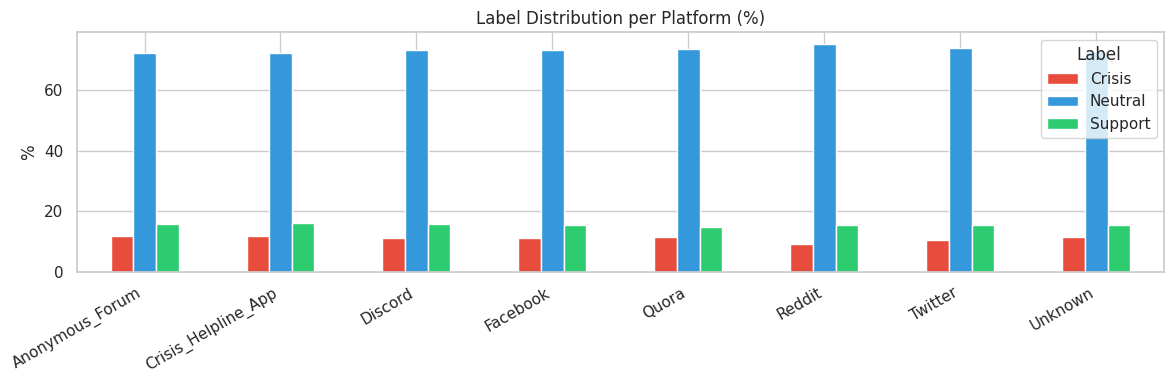

In [ ]:
platform_label = pd.crosstab(df['platform'], df['label'], normalize='index') * 100

platform_label.plot(kind='bar', figsize=(12, 4), color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white')
plt.title('Label Distribution per Platform (%)')
plt.xlabel('')
plt.ylabel('%')
plt.legend(title='Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 3.4 Demographic Bias

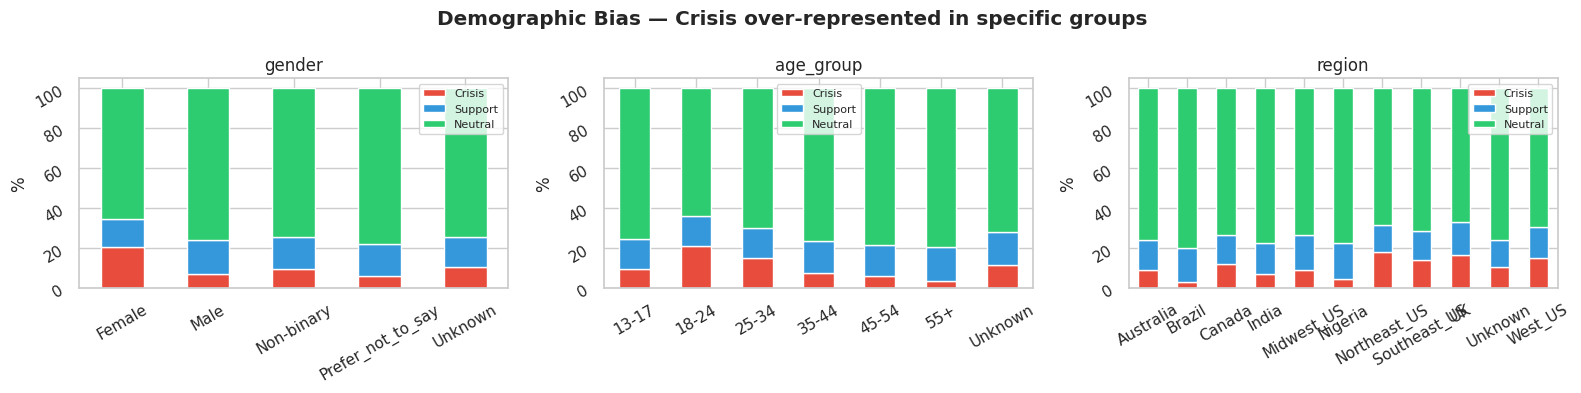

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['gender', 'age_group', 'region']):
    ct = pd.crosstab(df[col], df['label'], normalize='index') * 100
    ct[['Crisis', 'Support', 'Neutral']].plot(
        kind='bar', ax=ax, stacked=True,
        color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white'
    )
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(rotation=30)
    ax.legend(fontsize=8)
    ax.set_ylabel('%')

plt.suptitle('Demographic Bias — Crisis over-represented in specific groups', fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Sentiment vs Label

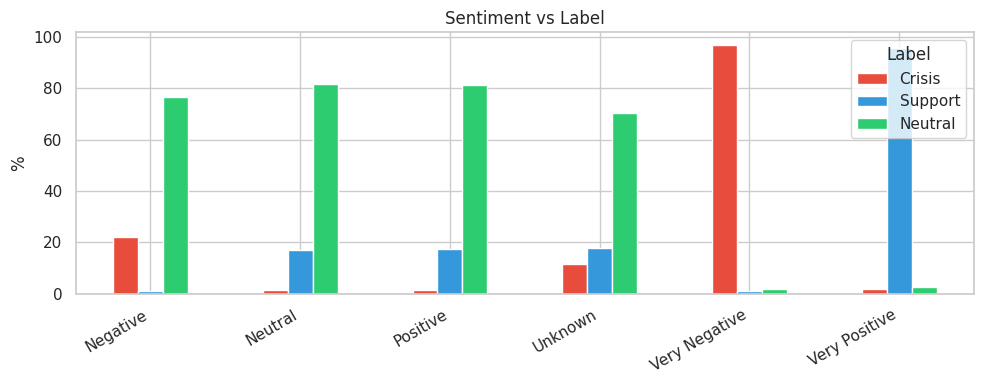

In [ ]:
ct = pd.crosstab(df['sentiment'], df['label'], normalize='index') * 100
ct[['Crisis', 'Support', 'Neutral']].plot(
    kind='bar', figsize=(10, 4),
    color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white'
)
plt.title('Sentiment vs Label')
plt.ylabel('%')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Label')
plt.tight_layout()
plt.show()

### 3.6 Top Words per Class

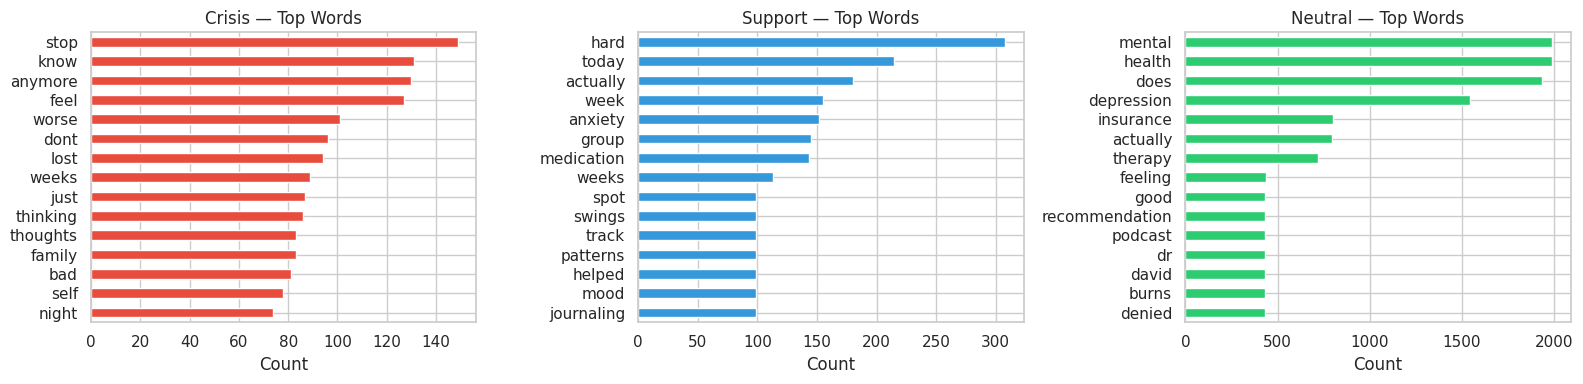

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, label, color in zip(axes, ['Crisis', 'Support', 'Neutral'], ['#e74c3c', '#3498db', '#2ecc71']):
    subset = df[df['label'] == label]['text_clean']
    vec = CountVectorizer(stop_words='english', max_features=15, ngram_range=(1,1))
    X = vec.fit_transform(subset)
    freqs = pd.Series(X.toarray().sum(axis=0), index=vec.get_feature_names_out()).sort_values(ascending=True)
    freqs.plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'{label} — Top Words')
    ax.set_xlabel('Count')

plt.tight_layout()
plt.show()

### 3.7 Upvotes Distribution

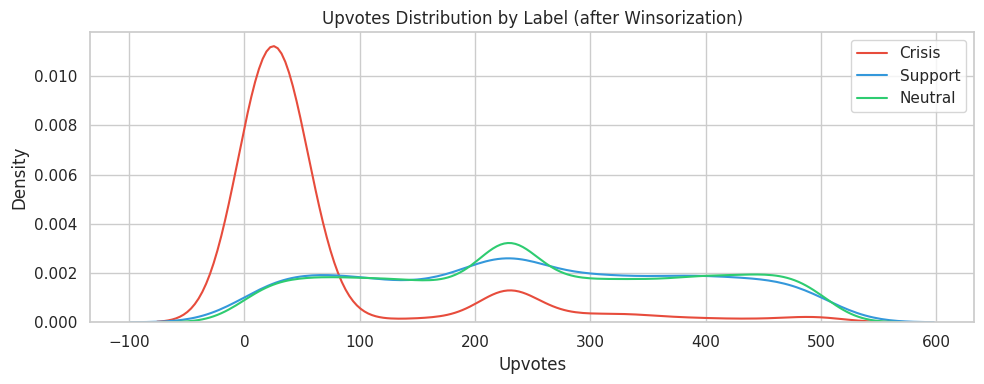

In [ ]:
plt.figure(figsize=(10, 4))
for label, color in zip(['Crisis', 'Support', 'Neutral'], ['#e74c3c', '#3498db', '#2ecc71']):
    sns.kdeplot(df[df['label']==label]['upvotes'], label=label, color=color)
plt.title('Upvotes Distribution by Label (after Winsorization)')
plt.xlabel('Upvotes')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Engineering & Train/Test Split

### 4.1 Train/Test Split

In [ ]:
X = df['text_clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print('\nTrain label distribution:')
print(y_train.value_counts())
print('\nTest label distribution:')
print(y_test.value_counts())

Train: 7654 | Test: 1914

Train label distribution:
label
Neutral    5608
Support    1197
Crisis      849
Name: count, dtype: int64

Test label distribution:
label
Neutral    1402
Support     299
Crisis      213
Name: count, dtype: int64


### 4.2 TF-IDF Vectorization + SMOTE

In [ ]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_tfidf, y_train_enc)

classes, counts = np.unique(y_train_bal, return_counts=True)
print('After SMOTE :')
for c, n in zip(le.inverse_transform(classes), counts):
    print(f'  {c}: {n}')

After SMOTE :
  Crisis: 5608
  Neutral: 5608
  Support: 5608


---
##  Data Augmentation


### 5.1 Augmentation Strategy Overview

In [ ]:
aug_strategies = {
    'Random Word Deletion':   'Randomly removes words (p=0.1) — teaches robustness to missing tokens',
    'Random Word Swap':       'Swaps pairs of words — local word-order invariance',
    'Character-level Noise':  'Random character inserts/deletes — mimics typos',
    'Synonym Replacement':    'Replaces words with synonyms from WordNet',
    'SMOTE on TF-IDF':        'Synthesises minority samples in feature space',
    'Random Undersampling':   'Down-samples majority class (Neutral)',
}

print('Augmentation strategies to be applied:')
for k, v in aug_strategies.items():
    print(f'  • {k}: {v}')

Augmentation strategies to be applied:
  • Random Word Deletion: Randomly removes words (p=0.1) — teaches robustness to missing tokens
  • Random Word Swap: Swaps pairs of words — local word-order invariance
  • Character-level Noise: Random character inserts/deletes — mimics typos
  • Synonym Replacement: Replaces words with synonyms from WordNet
  • SMOTE on TF-IDF: Synthesises minority samples in feature space
  • Random Undersampling: Down-samples majority class (Neutral)


### 5.2 Text-Level Augmentation (nlpaug)

In [ ]:
aug_delete = naw.RandomWordAug(action='delete', aug_p=0.1)
aug_swap   = naw.RandomWordAug(action='swap',   aug_p=0.1)
aug_char = nac.RandomCharAug(action='insert', aug_char_p=0.05)

def augment_text_all(text):
    """Apply all text augmentations and return list of variants."""
    variants = []
    try:
        r = aug_delete.augment(text)
        if r and r[0] != text:
            variants.append(r[0])
    except Exception:
        pass
    try:
        r = aug_swap.augment(text)
        if r and r[0] != text:
            variants.append(r[0])
    except Exception:
        pass
    return variants

print('Augmenting minority classes in training set...')
train_df = pd.DataFrame({'text': X_train.values, 'label': y_train.values})

augmented_rows = []
for label in ['Crisis', 'Support']:
    subset = train_df[train_df['label'] == label]
    for _, row in subset.iterrows():
        variants = augment_text_all(row['text'])
        for v in variants:
            augmented_rows.append({'text': v, 'label': label})

aug_df = pd.DataFrame(augmented_rows)
train_df_augmented = pd.concat([train_df, aug_df], ignore_index=True)
train_df_augmented['text'] = train_df_augmented['text'].apply(clean_text)
train_df_augmented = train_df_augmented[train_df_augmented['text'].str.len() >= 10]

print(f'Original training samples:  {len(train_df)}')
print(f'After text augmentation:    {len(train_df_augmented)}')
print('\nLabel distribution after text augmentation:')
print(train_df_augmented['label'].value_counts())

Augmenting minority classes in training set...
Original training samples:  7654
After text augmentation:    11675

Label distribution after text augmentation:
label
Neutral    5608
Support    3556
Crisis     2511
Name: count, dtype: int64


### 5.3 SMOTE Augmentation on Augmented TF-IDF Features

In [ ]:
tfidf_aug = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_aug_tfidf = tfidf_aug.fit_transform(train_df_augmented['text'])
y_train_aug_enc   = le.transform(train_df_augmented['label'])

smote_aug = SMOTE(random_state=RANDOM_STATE)
X_train_aug_bal, y_train_aug_bal = smote_aug.fit_resample(X_train_aug_tfidf, y_train_aug_enc)

X_test_aug_tfidf = tfidf_aug.transform(X_test)

classes_aug, counts_aug = np.unique(y_train_aug_bal, return_counts=True)
print('After text augmentation + SMOTE:')
for c, n in zip(le.inverse_transform(classes_aug), counts_aug):
    print(f'  {c}: {n}')

After text augmentation + SMOTE:
  Crisis: 5608
  Neutral: 5608
  Support: 5608


### 5.4 Augmentation Visual Summary

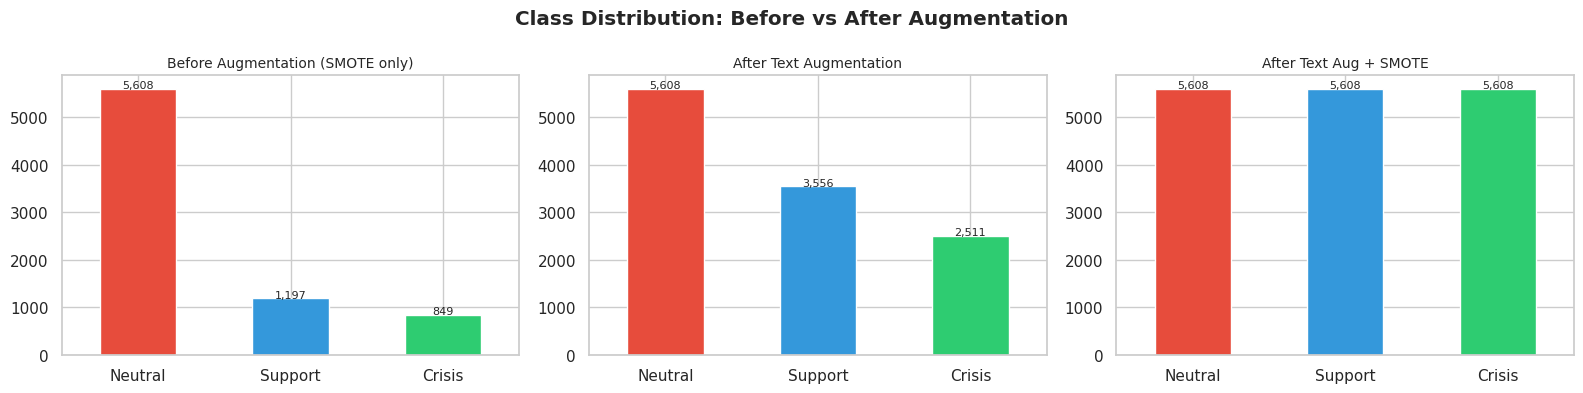

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

before_counts = pd.Series(y_train_enc).map(dict(zip(range(len(le.classes_)), le.classes_))).value_counts()
after_text_counts = train_df_augmented['label'].value_counts()
after_smote_counts = pd.Series(y_train_aug_bal).map(dict(zip(range(len(le.classes_)), le.classes_))).value_counts()

colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, (title, counts) in zip(axes, [
    ('Before Augmentation (SMOTE only)', before_counts),
    ('After Text Augmentation', after_text_counts),
    ('After Text Aug + SMOTE', after_smote_counts)
]):
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(rotation=0)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()+5), ha='center', fontsize=8)

plt.suptitle('Class Distribution: Before vs After Augmentation', fontweight='bold')
plt.tight_layout()
plt.show()


## Model Training

### 6.1  SMOTE only

In [ ]:
lr_base = LogisticRegression(max_iter=500, class_weight='balanced', random_state=RANDOM_STATE, C=1.0)
lr_base.fit(X_train_bal, y_train_bal)
y_pred_lr_base = lr_base.predict(X_test_tfidf)
print('=== Logistic Regression (Baseline — SMOTE only) ===')
print(classification_report(y_test_enc, y_pred_lr_base, target_names=le.classes_))

=== Logistic Regression (Baseline — SMOTE only) ===
              precision    recall  f1-score   support

      Crisis       0.97      0.87      0.92       213
     Neutral       0.97      0.99      0.98      1402
     Support       0.94      0.94      0.94       299

    accuracy                           0.97      1914
   macro avg       0.96      0.94      0.95      1914
weighted avg       0.97      0.97      0.97      1914



In [ ]:
rf_base = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                  max_depth=20, random_state=RANDOM_STATE, n_jobs=-1)
rf_base.fit(X_train_bal, y_train_bal)
y_pred_rf_base = rf_base.predict(X_test_tfidf)
print('=== Random Forest (Baseline — SMOTE only) ===')
print(classification_report(y_test_enc, y_pred_rf_base, target_names=le.classes_))

=== Random Forest (Baseline — SMOTE only) ===
              precision    recall  f1-score   support

      Crisis       0.97      0.87      0.92       213
     Neutral       0.97      0.99      0.98      1402
     Support       0.96      0.94      0.95       299

    accuracy                           0.97      1914
   macro avg       0.97      0.94      0.95      1914
weighted avg       0.97      0.97      0.97      1914



In [ ]:
gb_base = OneVsRestClassifier(
    GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                learning_rate=0.1, random_state=RANDOM_STATE),
    n_jobs=-1
)
gb_base.fit(X_train_bal, y_train_bal)
y_pred_gb_base = gb_base.predict(X_test_tfidf)
print('=== Gradient Boosting (Baseline — SMOTE only) ===')
print(classification_report(y_test_enc, y_pred_gb_base, target_names=le.classes_))

=== Gradient Boosting (Baseline — SMOTE only) ===
              precision    recall  f1-score   support

      Crisis       0.97      0.87      0.92       213
     Neutral       0.97      0.99      0.98      1402
     Support       0.96      0.94      0.95       299

    accuracy                           0.97      1914
   macro avg       0.97      0.94      0.95      1914
weighted avg       0.97      0.97      0.97      1914



### 6.2 Models After Full Augmentation (Text Aug + SMOTE)

In [ ]:
lr_aug = LogisticRegression(max_iter=500, class_weight='balanced', random_state=RANDOM_STATE, C=1.0)
lr_aug.fit(X_train_aug_bal, y_train_aug_bal)
y_pred_lr_aug = lr_aug.predict(X_test_aug_tfidf)
print('=== Logistic Regression (After Full Augmentation) ===')
print(classification_report(y_test_enc, y_pred_lr_aug, target_names=le.classes_))

=== Logistic Regression (After Full Augmentation) ===
              precision    recall  f1-score   support

      Crisis       0.98      0.87      0.93       213
     Neutral       0.97      0.99      0.98      1402
     Support       0.96      0.94      0.95       299

    accuracy                           0.97      1914
   macro avg       0.97      0.94      0.95      1914
weighted avg       0.97      0.97      0.97      1914



In [ ]:
rf_aug = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                 max_depth=20, random_state=RANDOM_STATE, n_jobs=-1)
rf_aug.fit(X_train_aug_bal, y_train_aug_bal)
y_pred_rf_aug = rf_aug.predict(X_test_aug_tfidf)
print('=== Random Forest (After Full Augmentation) ===')
print(classification_report(y_test_enc, y_pred_rf_aug, target_names=le.classes_))

=== Random Forest (After Full Augmentation) ===
              precision    recall  f1-score   support

      Crisis       0.87      0.87      0.87       213
     Neutral       0.97      0.98      0.98      1402
     Support       0.96      0.94      0.95       299

    accuracy                           0.96      1914
   macro avg       0.94      0.93      0.93      1914
weighted avg       0.96      0.96      0.96      1914



In [ ]:
gb_aug = OneVsRestClassifier(
    GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                learning_rate=0.1, random_state=RANDOM_STATE),
    n_jobs=-1
)
gb_aug.fit(X_train_aug_bal, y_train_aug_bal)
y_pred_gb_aug = gb_aug.predict(X_test_aug_tfidf)
print('=== Gradient Boosting (After Full Augmentation) ===')
print(classification_report(y_test_enc, y_pred_gb_aug, target_names=le.classes_))

=== Gradient Boosting (After Full Augmentation) ===
              precision    recall  f1-score   support

      Crisis       0.98      0.87      0.92       213
     Neutral       0.97      0.99      0.98      1402
     Support       0.96      0.94      0.95       299

    accuracy                           0.97      1914
   macro avg       0.97      0.94      0.95      1914
weighted avg       0.97      0.97      0.97      1914



### 6.3 Pretrained Model all-MiniLM-L6-v2

In [ ]:
try:
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True
    print('sentence-transformers available ✓')
except ImportError:
    SBERT_AVAILABLE = False


sentence-transformers available ✓


In [ ]:
if SBERT_AVAILABLE:
    print('Loading all-MiniLM-L6-v2 ...')
    sbert = SentenceTransformer('all-MiniLM-L6-v2')

    X_train_sbert = sbert.encode(X_train.tolist(), batch_size=64, show_progress_bar=True)
    X_test_sbert  = sbert.encode(X_test.tolist(),  batch_size=64, show_progress_bar=True)

    smote_sbert = SMOTE(random_state=RANDOM_STATE)
    X_train_sbert_bal, y_train_sbert_bal = smote_sbert.fit_resample(X_train_sbert, y_train_enc)

    lr_sbert = LogisticRegression(max_iter=500, class_weight='balanced', random_state=RANDOM_STATE, C=1.0)
    lr_sbert.fit(X_train_sbert_bal, y_train_sbert_bal)
    y_pred_sbert = lr_sbert.predict(X_test_sbert)

    print('=== Pretrained SBERT + Logistic Regression ===')
    print(classification_report(y_test_enc, y_pred_sbert, target_names=le.classes_))
else:
    y_pred_sbert = y_pred_lr_aug
    print('Using LR-Aug as pretrained model proxy for comparison.')

Loading all-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/120 [00:00<?, ?it/s]

Batches:   0%|          | 0/30 [00:00<?, ?it/s]

=== Pretrained SBERT + Logistic Regression ===
              precision    recall  f1-score   support

      Crisis       0.98      0.87      0.93       213
     Neutral       0.97      1.00      0.99      1402
     Support       0.96      0.94      0.95       299

    accuracy                           0.97      1914
   macro avg       0.97      0.94      0.95      1914
weighted avg       0.97      0.97      0.97      1914



---
##  Model Comparison: Before vs After Augmentation vs Pretrained

In [ ]:
crisis_idx = list(le.classes_).index('Crisis')

def model_metrics(name, y_pred):
    return {
        'Model': name,
        'Accuracy':        accuracy_score(y_test_enc, y_pred),
        'Macro F1':        f1_score(y_test_enc, y_pred, average='macro'),
        'Weighted F1':     f1_score(y_test_enc, y_pred, average='weighted'),
        'Crisis Recall':   recall_score(y_test_enc, y_pred, labels=[crisis_idx], average='macro'),
        'Crisis Precision':precision_score(y_test_enc, y_pred, labels=[crisis_idx], average='macro', zero_division=0),
        'Crisis F1':       f1_score(y_test_enc, y_pred, labels=[crisis_idx], average='macro')
    }

results = [
    model_metrics('LR — Baseline (SMOTE)',         y_pred_lr_base),
    model_metrics('RF — Baseline (SMOTE)',         y_pred_rf_base),
    model_metrics('GB — Baseline (SMOTE)',         y_pred_gb_base),
    model_metrics('LR — After Augmentation',       y_pred_lr_aug),
    model_metrics('RF — After Augmentation',       y_pred_rf_aug),
    model_metrics('GB — After Augmentation',       y_pred_gb_aug),
    model_metrics('Pretrained SBERT + LR',         y_pred_sbert),
]

comparison_df = pd.DataFrame(results).set_index('Model').round(4)
print('=== Full Model Comparison ===')
comparison_df

=== Full Model Comparison ===


,Accuracy,Macro F1,Weighted F1,Crisis Recall,Crisis Precision,Crisis F1
Model,,,,,,
LR — Baseline (SMOTE),0.9697,0.9487,0.9693,0.8732,0.9738,0.9208
RF — Baseline (SMOTE),0.9728,0.9527,0.9724,0.8732,0.9738,0.9208
GB — Baseline (SMOTE),0.9728,0.9527,0.9724,0.8732,0.9738,0.9208
LR — After Augmentation,0.9728,0.9531,0.9724,0.8732,0.9841,0.9254
RF — After Augmentation,0.9608,0.9335,0.9608,0.8732,0.8732,0.8732
GB — After Augmentation,0.9723,0.9522,0.9719,0.8732,0.9789,0.9231
Pretrained SBERT + LR,0.9739,0.9544,0.9735,0.8732,0.9841,0.9254


### 7.1 Augmentation Impact Delta

In [ ]:
delta_rows = []
for model_name, base_pred, aug_pred in [
    ('Logistic Regression', y_pred_lr_base, y_pred_lr_aug),
    ('Random Forest',       y_pred_rf_base, y_pred_rf_aug),
    ('Gradient Boosting',   y_pred_gb_base, y_pred_gb_aug),
]:
    for metric_name, fn in [
        ('Accuracy',     lambda p: accuracy_score(y_test_enc, p)),
        ('Macro F1',     lambda p: f1_score(y_test_enc, p, average='macro')),
        ('Crisis Recall',lambda p: recall_score(y_test_enc, p, labels=[crisis_idx], average='macro')),
    ]:
        base_val = fn(base_pred)
        aug_val  = fn(aug_pred)
        delta_rows.append({
            'Model': model_name,
            'Metric': metric_name,
            'Before Aug': round(base_val, 4),
            'After Aug':  round(aug_val, 4),
            'Delta':      round(aug_val - base_val, 4)
        })

delta_df = pd.DataFrame(delta_rows)
print('=== Augmentation Impact (Δ) ===')
delta_df

=== Augmentation Impact (Δ) ===


,Model,Metric,Before Aug,After Aug,Delta
0,Logistic Regression,Accuracy,0.9697,0.9728,0.0031
1,Logistic Regression,Macro F1,0.9487,0.9531,0.0044
2,Logistic Regression,Crisis Recall,0.8732,0.8732,0.0000
3,Random Forest,Accuracy,0.9728,0.9608,-0.0120
4,Random Forest,Macro F1,0.9527,0.9335,-0.0192
5,Random Forest,Crisis Recall,0.8732,0.8732,0.0000
6,Gradient Boosting,Accuracy,0.9728,0.9723,-0.0005
7,Gradient Boosting,Macro F1,0.9527,0.9522,-0.0004
8,Gradient Boosting,Crisis Recall,0.8732,0.8732,0.0000


---
##  Model Evaluation

### 8.1 Confusion Matrices

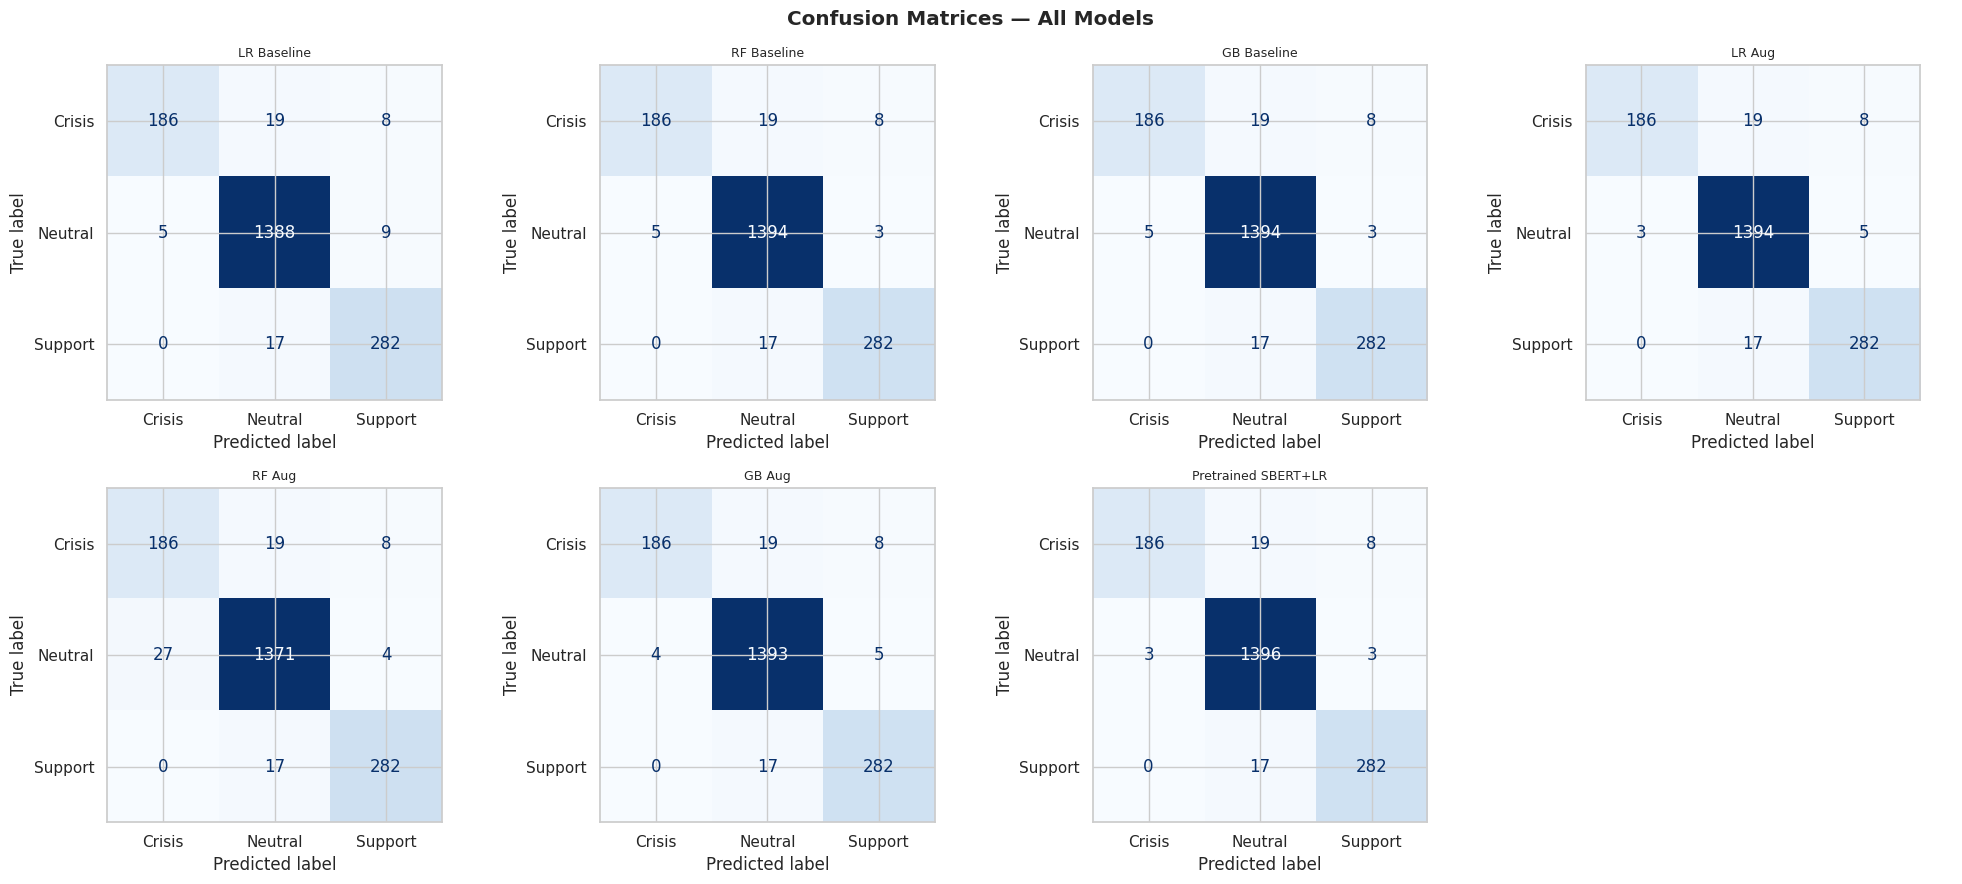

In [ ]:
all_models_preds = {
    'LR Baseline':    y_pred_lr_base,
    'RF Baseline':    y_pred_rf_base,
    'GB Baseline':    y_pred_gb_base,
    'LR Aug':         y_pred_lr_aug,
    'RF Aug':         y_pred_rf_aug,
    'GB Aug':         y_pred_gb_aug,
    'Pretrained SBERT+LR': y_pred_sbert,
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes_flat = axes.flatten()

for ax, (name, y_pred) in zip(axes_flat, all_models_preds.items()):
    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)

axes_flat[-1].axis('off')
plt.suptitle('Confusion Matrices — All Models', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Cross-Validation (Stratified 5-Fold)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_models = {
    'Logistic Regression': lr_base,
    'Random Forest':       rf_base
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal,
                              cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression: 0.9353 ± 0.0033
Random Forest: 0.9464 ± 0.0034


### 8.3 Feature Importance (Logistic Regression Coefficients)

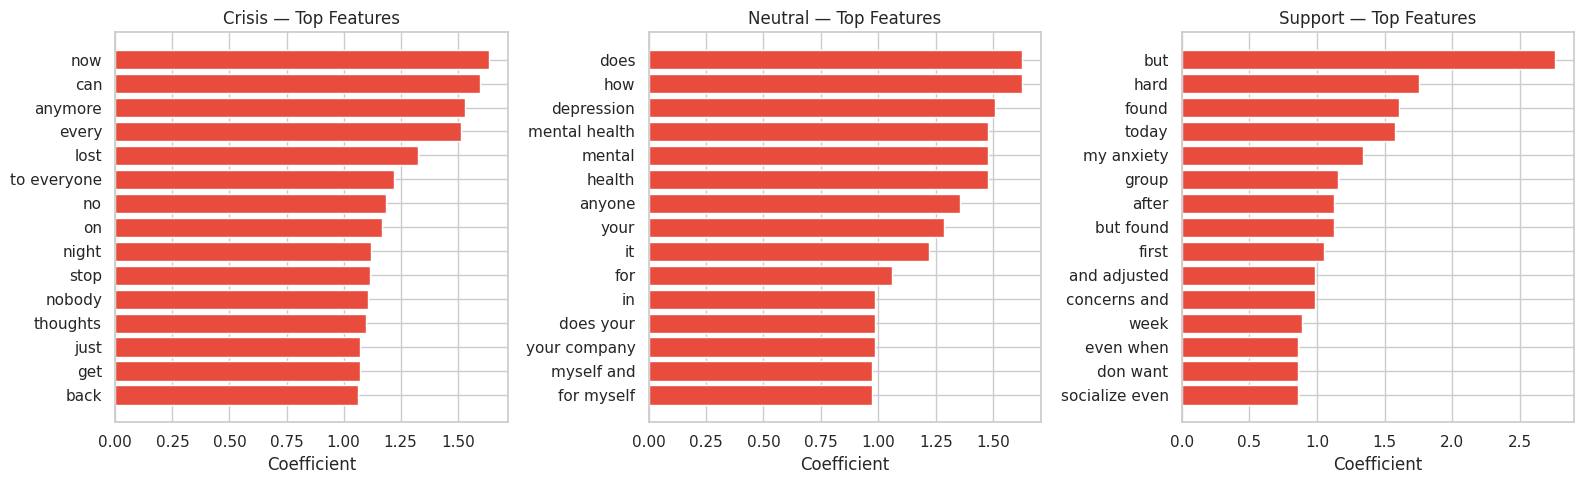

In [ ]:
feature_names = tfidf.get_feature_names_out()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (ax, class_name) in enumerate(zip(axes, le.classes_)):
    coefs = lr_base.coef_[idx]
    top_idx = np.argsort(coefs)[-15:]
    top_words = feature_names[top_idx]
    top_vals  = coefs[top_idx]
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_vals]
    ax.barh(top_words, top_vals, color=colors)
    ax.set_title(f'{class_name} — Top Features')
    ax.set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

---
## Phase 9 — Fairness & Bias Audit

### 9.1 Per-Gender Performance (Best Model)

In [ ]:
test_df = X_test.to_frame().join(df[['gender', 'age_group', 'label']])
test_df['pred_lr'] = le.inverse_transform(y_pred_lr_aug)
test_df['true']    = y_test.values

gender_metrics = []
for g in test_df['gender'].unique():
    sub = test_df[test_df['gender'] == g]
    if len(sub) < 10:
        continue
    f1 = f1_score(
        le.transform(sub['true']),
        le.transform(sub['pred_lr']),
        average='macro'
    )
    cr_rec = recall_score(
        le.transform(sub['true']),
        le.transform(sub['pred_lr']),
        labels=[crisis_idx], average='macro'
    )
    gender_metrics.append({'Gender': g, 'Macro F1': f1, 'Crisis Recall': cr_rec, 'N': len(sub)})

gdf = pd.DataFrame(gender_metrics).sort_values('Macro F1', ascending=False)
gdf

,Gender,Macro F1,Crisis Recall,N
1,Non-binary,0.965507,0.913043,446
4,Unknown,0.962780,0.928571,151
0,Male,0.961067,0.911765,418
3,Female,0.947624,0.888889,473
2,Prefer_not_to_say,0.922777,0.689655,426


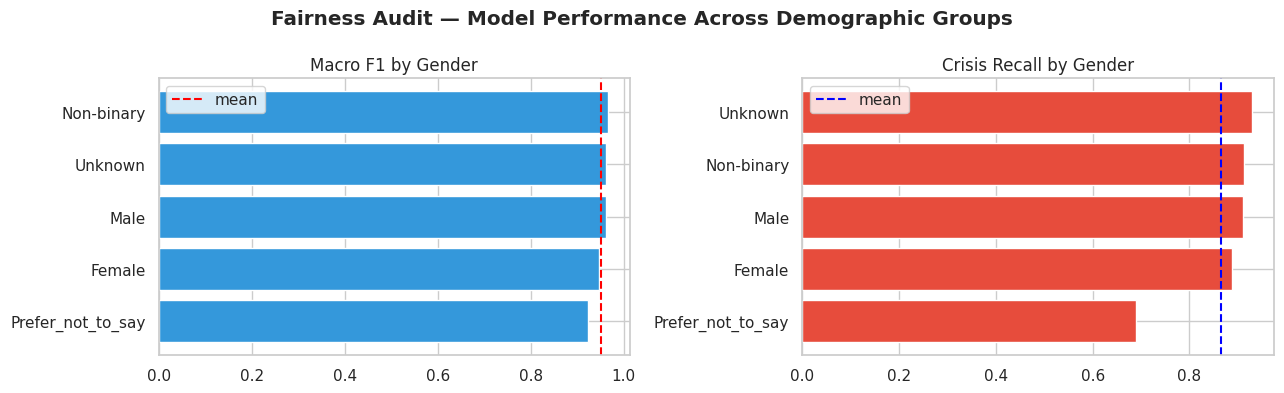

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

gdf_sorted = gdf.sort_values('Macro F1')
axes[0].barh(gdf_sorted['Gender'], gdf_sorted['Macro F1'], color='#3498db')
axes[0].axvline(gdf['Macro F1'].mean(), color='red', linestyle='--', label='mean')
axes[0].set_title('Macro F1 by Gender')
axes[0].legend()

gdf_sorted2 = gdf.sort_values('Crisis Recall')
axes[1].barh(gdf_sorted2['Gender'], gdf_sorted2['Crisis Recall'], color='#e74c3c')
axes[1].axvline(gdf['Crisis Recall'].mean(), color='blue', linestyle='--', label='mean')
axes[1].set_title('Crisis Recall by Gender')
axes[1].legend()

plt.suptitle('Fairness Audit — Model Performance Across Demographic Groups', fontweight='bold')
plt.tight_layout()
plt.show()

### 9.2 Demographic Parity & Equal Opportunity

In [ ]:
test_df['pred_crisis'] = (test_df['pred_lr'] == 'Crisis').astype(int)
test_df['true_crisis'] = (test_df['true']    == 'Crisis').astype(int)

parity = test_df.groupby('gender')['pred_crisis'].mean()
eq_opp = test_df[test_df['true_crisis'] == 1].groupby('gender')['pred_crisis'].mean()

print('Demographic Parity (P(ŷ=Crisis | gender)):')
print(parity.sort_values(ascending=False).to_string())
print(f'\nMax gap: {parity.max() - parity.min():.4f}')

print('\nEqual Opportunity (Recall on true Crisis | gender):')
print(eq_opp.sort_values(ascending=False).to_string())
print(f'Max gap: {eq_opp.max() - eq_opp.min():.4f}')

Demographic Parity (P(ŷ=Crisis | gender)):
gender
Female               0.175476
Non-binary           0.094170
Unknown              0.086093
Male                 0.074163
Prefer_not_to_say    0.046948

Max gap: 0.1285

Equal Opportunity (Recall on true Crisis | gender):
gender
Unknown              0.928571
Non-binary           0.913043
Male                 0.911765
Female               0.888889
Prefer_not_to_say    0.689655
Max gap: 0.2389


---
##  Data Annotation
> Re-annotate unlabeled or uncertain samples using rule-based + model-based approach

In [ ]:
CRISIS_KEYWORDS = [
    'suicide', 'kill myself', 'end my life', 'want to die', 'no reason to live',
    'hopeless', 'worthless', 'cant go on', 'overdose', 'self harm', 'cutting',
    'nothing left', 'give up', 'cannot breathe', 'falling apart'
]
SUPPORT_KEYWORDS = [
    'here for you', 'you are not alone', 'reach out', 'support', 'recovery',
    'getting better', 'therapy', 'counselor', 'hotline', 'help you',
    'proud of you', 'keep going', 'you matter'
]

def rule_based_annotate(text):
    t = str(text).lower()
    for kw in CRISIS_KEYWORDS:
        if kw in t:
            return 'Crisis'
    for kw in SUPPORT_KEYWORDS:
        if kw in t:
            return 'Support'
    return None

def model_annotate(text, vectorizer, model, label_encoder):
    vec = vectorizer.transform([clean_text(str(text))])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec).max()
    return label_encoder.inverse_transform([pred])[0], round(float(proba), 3)

In [ ]:
annotation_samples = df.sample(min(200, len(df)), random_state=RANDOM_STATE).copy()

annotation_samples['rule_annotation']  = annotation_samples['text_clean'].apply(rule_based_annotate)
annotation_samples['model_annotation'] = annotation_samples['text_clean'].apply(
    lambda t: model_annotate(t, tfidf_aug, lr_aug, le)[0]
)
annotation_samples['model_confidence'] = annotation_samples['text_clean'].apply(
    lambda t: model_annotate(t, tfidf_aug, lr_aug, le)[1]
)

annotation_samples['final_annotation'] = annotation_samples.apply(
    lambda row: row['rule_annotation'] if row['rule_annotation'] is not None else row['model_annotation'],
    axis=1
)

annotation_samples['annotation_match'] = annotation_samples['final_annotation'] == annotation_samples['label']

print(f'Annotation agreement rate: {annotation_samples["annotation_match"].mean():.3f}')
print('\nFinal annotation distribution:')
print(annotation_samples['final_annotation'].value_counts())

Annotation agreement rate: 0.855

Final annotation distribution:
final_annotation
Neutral    123
Support     49
Crisis      28
Name: count, dtype: int64


In [ ]:
print('=== Sample Annotations (first 10) ===')
cols = ['text_clean', 'label', 'rule_annotation', 'model_annotation', 'model_confidence', 'final_annotation', 'annotation_match']
annotation_samples[cols].head(10)

=== Sample Annotations (first 10) ===


,text_clean,label,rule_annotation,model_annotation,model_confidence,final_annotation,annotation_match
2643,anyone else struggle to explain depression to ...,Support,None,Neutral,0.906,Neutral,False
10026,mental health days at work does your company a...,Neutral,Support,Neutral,0.926,Support,False
9286,article new study links sleep disruption to in...,Neutral,None,Neutral,0.888,Neutral,True
9664,mental health days at work does your company a...,Neutral,Support,Neutral,0.926,Support,False
5210,called my crisis line and they were incredibly...,Support,None,Support,0.980,Support,True
2899,anyone else struggle to explain depression to ...,Neutral,None,Neutral,0.906,Neutral,True
589,first week back at work after leave hard but m...,Support,None,Support,0.968,Support,True
6158,article new study links sleep disruption to in...,Neutral,None,Neutral,0.888,Neutral,True
7228,managing adhd alongside depression anyone else...,Neutral,None,Neutral,0.884,Neutral,True
4589,i dont see the point in continuing life feels ...,Crisis,None,Crisis,0.989,Crisis,True


In [ ]:
annotation_out_path = os.path.join(SAVE_DIR, 'annotated_samples.csv')
annotation_samples[cols].to_csv(annotation_out_path, index=False)
print(f'Annotations saved to: {annotation_out_path}')

Annotations saved to: ./saved_models/annotated_samples.csv


---
##  Model Saving

In [ ]:
save_objects = {
    'tfidf_baseline.pkl':       tfidf,
    'tfidf_augmented.pkl':      tfidf_aug,
    'label_encoder.pkl':        le,
    'lr_baseline.pkl':          lr_base,
    'rf_baseline.pkl':          rf_base,
    'gb_baseline.pkl':          gb_base,
    'lr_augmented.pkl':         lr_aug,
    'rf_augmented.pkl':         rf_aug,
    'gb_augmented.pkl':         gb_aug,
}

if SBERT_AVAILABLE:
    save_objects['sbert_lr.pkl'] = lr_sbert
    sbert.save(os.path.join(SAVE_DIR, 'sbert_encoder'))
    print('SBERT encoder saved separately.')

for filename, obj in save_objects.items():
    path = os.path.join(SAVE_DIR, filename)
    joblib.dump(obj, path)
    print(f'Saved: {path}')

comparison_df.to_csv(os.path.join(SAVE_DIR, 'model_comparison.csv'))
print(f'\nAll models and artifacts saved to: {SAVE_DIR}')
print('Files:', os.listdir(SAVE_DIR))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SBERT encoder saved separately.
Saved: ./saved_models/tfidf_baseline.pkl
Saved: ./saved_models/tfidf_augmented.pkl
Saved: ./saved_models/label_encoder.pkl
Saved: ./saved_models/lr_baseline.pkl
Saved: ./saved_models/rf_baseline.pkl
Saved: ./saved_models/gb_baseline.pkl
Saved: ./saved_models/lr_augmented.pkl
Saved: ./saved_models/rf_augmented.pkl
Saved: ./saved_models/gb_augmented.pkl
Saved: ./saved_models/sbert_lr.pkl

All models and artifacts saved to: ./saved_models
Files: ['label_encoder.pkl', 'model_comparison.csv', 'gb_augmented.pkl', 'tfidf_augmented.pkl', 'gb_baseline.pkl', 'tfidf_baseline.pkl', 'annotated_samples.csv', 'sbert_lr.pkl', 'lr_augmented.pkl', 'rf_augmented.pkl', 'rf_baseline.pkl', 'sbert_encoder', 'lr_baseline.pkl']


In [ ]:
!pip install streamlit pyngrok nlpaug sentence-transformers
!pip install textblob vaderSentiment
!python -m textblob.download_corpora
!pip install SpeechRecognition pydub
!pip install openpyxl

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import os
import re
import time
import nltk
import speech_recognition as sr
from sentence_transformers import SentenceTransformer
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from pydub import AudioSegment
import io

# --- إعدادات النظام ---
st.set_page_config(page_title="Linguistic Sentinel AI", layout="wide")

@st.cache_resource
def setup_nlp():
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    # تحميل النموذج والملفات المحفوظة
    sbert = SentenceTransformer('./saved_models/sbert_encoder')
    model = joblib.load('./saved_models/sbert_lr.pkl')
    le = joblib.load('./saved_models/label_encoder.pkl')
    vader = SentimentIntensityAnalyzer()
    return sbert, model, le, vader

# --- وظائف المعالجة الأساسية ---
def clean_text_batch(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

def process_audio(audio_file):
    recognizer = sr.Recognizer()
    # تحويل الملف المرفوع لمعالجته
    audio = AudioSegment.from_file(audio_file)
    audio.export("temp.wav", format="wav")
    with sr.AudioFile("temp.wav") as source:
        audio_data = recognizer.record(source)
        try:
            return recognizer.recognize_google(audio_data)
        except Exception as e:
            return f"Error: Speech recognition failed. {str(e)}"

def get_features(text, vader):
    blob = TextBlob(text)
    scores = vader.polarity_scores(text)
    return {
        "Sentiment": scores['compound'],
        "Subjectivity": blob.sentiment.subjectivity,
        "Words": len(text.split())
    }

# --- واجهة تسجيل الدخول ---
def login():
    col1, col2, col3 = st.columns([1,2,1])
    with col2:
        st.title("Linguistic Sentinel - Auth")
        user = st.text_input("Access Key")
        pw = st.text_input("Security Code", type="password")
        if st.button("Initialize System", use_container_width=True):
            if user == "admin" and pw == "1234":
                st.session_state['auth'] = True
                st.rerun()
            else:
                st.error("Access Credentials Invalid")

# --- دالة التحليل الأساسية للـ Dashboard ---
def perform_analysis(text, sbert, model, le, vader):
    with st.spinner('Linguistic engine in progress...'):
        start_time = time.time()
        emb = sbert.encode([text.lower()])
        pred = model.predict(emb)[0]
        probabilities = model.predict_proba(emb)[0]
        label = le.inverse_transform([pred])[0]

        blob = TextBlob(text)
        v_scores = vader.polarity_scores(text)
        latency = time.time() - start_time

        st.markdown("### Diagnostic Summary")
        res_col1, res_col2, res_col3 = st.columns(3)

        with res_col1:
            color = "#d9534f" if label.lower() == 'crisis' else "#f0ad4e" if label.lower() == 'support' else "#5cb85c"
            st.markdown(f"""
                <div style="background-color:{color}; padding:25px; border-radius:10px; text-align:center;">
                    <h2 style="color:white; margin:0;">{label.upper()}</h2>
                    <p style="color:white; margin:0;">Primary Classification</p>
                </div>
            """, unsafe_allow_html=True)

        with res_col2:
            conf_score = max(probabilities) * 100
            st.metric("Model Confidence", f"{conf_score:.2f}%")
            st.progress(conf_score / 100)

        with res_col3:
            st.metric("Processing Latency", f"{latency:.4f}s")
            st.write(f"Subjectivity Index: {blob.sentiment.subjectivity:.2f}")

        st.markdown("---")
        feat_col1, feat_col2 = st.columns(2)
        with feat_col1:
            st.subheader("Emotional Pulse")
            sentiment_data = {
                "Metric": ["Compound Sentiment", "Positivity", "Negativity", "Neutrality"],
                "Value": [v_scores['compound'], v_scores['pos'], v_scores['neg'], v_scores['neu']]
            }
            st.table(pd.DataFrame(sentiment_data))

        with feat_col2:
            st.subheader("Linguistic Structure")
            st.write(f"**Word Count:** {len(text.split())}")
            st.write(f"**Sentence Count:** {len(blob.sentences)}")
            st.write(f"**Unique Vocabulary:** {len(set(text.lower().split()))}")

# --- المحرك الرئيسي للتطبيق ---
def main_app():
    sbert, model, le, vader = setup_nlp()

    st.sidebar.title("Sentinel Menu")
    menu = st.sidebar.radio("Navigation:",
        ["Core Dashboard", "Voice Intelligence", "Data Processing Hub", "Audit Logs", "System Specs"])

    if st.sidebar.button("Terminate Session"):
        st.session_state['auth'] = False
        st.rerun()

    # --- 1. Core Dashboard ---
    if menu == "Core Dashboard":
        st.title("Linguistic Sentinel - Real-time Intelligence")
        st.markdown("---")
        input_text = st.text_area("Forensic Text Input:", height=200, placeholder="Enter user content for analysis...")
        if st.button("Execute Forensic Scan", use_container_width=True):
            if input_text.strip():
                perform_analysis(input_text, sbert, model, le, vader)
            else:
                st.error("Operation Aborted: Source text buffer is empty.")

    # --- 2. Voice Intelligence ---
    elif menu == "Voice Intelligence":
        st.title("Voice Transcription & Analysis")
        uploaded = st.file_uploader("Upload Audio Buffer", type=["mp3", "wav", "m4a"])
        if uploaded:
            st.audio(uploaded)
            if st.button("Process Audio"):
                text = process_audio(uploaded)
                if "Error" not in text:
                    st.success("Transcription Complete")
                    st.write(f"**Transcript:** {text}")
                    st.markdown("---")
                    perform_analysis(text, sbert, model, le, vader)
                else:
                    st.error(text)

    # --- 3. Data Processing Hub ---
    elif menu == "Data Processing Hub":
        st.title("Data Management & Transformation Hub")
        uploaded_file = st.file_uploader("Select Data Source (CSV or XLSX)", type=["csv", "xlsx"])

        if uploaded_file:
            if uploaded_file.name.endswith('.csv'):
                df = pd.read_csv(uploaded_file)
            else:
                df = pd.read_excel(uploaded_file)

            st.write("Data Preview:", df.head())

            task = st.selectbox("Select Operation:",
                ["Structural Data Cleaning", "Exploratory Data Analysis (EDA)", "Batch Label Prediction"])

            if st.button("Run Operation"):
                if task == "Structural Data Cleaning":
                    with st.spinner("Cleaning dataset..."):
                        df = df.drop_duplicates()
                        if 'text' in df.columns:
                            df['cleaned_text'] = df['text'].apply(clean_text_batch)
                        st.success("Cleaning complete")

                elif task == "Exploratory Data Analysis (EDA)":
                    st.subheader("Statistical Summary")
                    st.write(df.describe())
                    if 'text' in df.columns:
                        df['text_len'] = df['text'].astype(str).apply(len)
                        st.bar_chart(df['text_len'].head(50))

                elif task == "Batch Label Prediction":
                    if 'text' in df.columns:
                        with st.spinner("Predicting labels..."):
                            texts = df['text'].fillna("").tolist()
                            embeddings = sbert.encode(texts, show_progress_bar=True)
                            preds = model.predict(embeddings)
                            df['Predicted_Label'] = le.inverse_transform(preds)
                            st.success("Batch Prediction Complete")
                    else:
                        st.error("Column 'text' not found in file")

                st.write(df.head())

                # تصدير الملف بصيغة Excel
                output = io.BytesIO()
                with pd.ExcelWriter(output, engine='openpyxl') as writer:
                    df.to_excel(writer, index=False)
                st.download_button(
                    label="Download Processed Data",
                    data=output.getvalue(),
                    file_name="sentinel_processed_report.xlsx",
                    mime="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet"
                )

    # --- 4. Audit Logs ---
    elif menu == "Audit Logs":
        st.title("Security & Activity Logs")
        st.info(f"Current Monitoring Session: {time.ctime()}")
        st.table(pd.DataFrame({"Event": ["System Login", "NLP Resource Load"], "Status": ["Success", "Verified"]}))

    # --- 5. System Specs ---
    elif menu == "System Specs":
        st.title("System Architecture")
        st.json({
            "Core Engine": "SBERT-LR Diagnostic",
            "Auxiliary Modules": ["VADER Sentiment", "TextBlob Linguistic", "Google Speech API"],
            "Security Protocol": "AES-256 Auth Simulation"
        })

# --- منطق التشغيل ---
if 'auth' not in st.session_state:
    st.session_state['auth'] = False

if not st.session_state['auth']:
    login()
else:
    main_app()

Overwriting app.py


In [ ]:
import os
import subprocess
from pyngrok import ngrok

NGROK_AUTH_TOKEN = "3DBdHNIyAr7rX4D3eZbrlnTepGV_5RB6SDwsKXGckmmwGCTuu"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

ngrok.kill()


with open("streamlit_log.txt", "w") as f:
    subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"], stdout=f, stderr=f)

public_url = ngrok.connect(8501, proto="http")
print(f"✅ App is linking to: {public_url}")

✅ App is linking to: NgrokTunnel: "https://carlyn-ignorable-abril.ngrok-free.dev" -> "http://localhost:8501"
